# Rendering elements as points with `as_points`

`spatialdata-plot` normally draws each element as its full geometry: a shape is
its polygon or circle, a labels element is its filled segmentation mask. Passing
`as_points=True` to `render_shapes()` or `render_labels()` instead draws **one dot
per element, placed at its centroid**. You keep *where* each object is and *what
colour* it has, but drop its size and outline.

This notebook shows the *how* and the *why*:

- what the option looks like on real data, for both shapes and labels;
- what it ignores (`outline_*`, `shape`, `contour_px`);
- the backend it picks and the ~50 000-element rule;
- and — the reason it exists — what it costs, measured. The headline: for
  **shapes** it is a large speed win; for **labels** it is mostly a change of
  *representation*, not speed.

We use a real Xenium human breast-cancer section (~168 000 cells) so the speed
numbers are meaningful rather than synthetic.

## Setup

The dataset is the Xenium replicate-1 human breast-cancer sample, converted to
the SpatialData Zarr format and hosted on the scverse example-data bucket. It is
~3.4 GB; `pooch` downloads it once and caches it, so re-runs are instant.

> This notebook is **not** re-executed in CI (the download is too large); its
> outputs are committed and trusted. Run it locally to reproduce them.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import time

import matplotlib.pyplot as plt
import numpy as np
import pooch

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the .pl accessor)
from spatialdata import SpatialData, bounding_box_query, rasterize

XENIUM_URL = (
    "https://s3.embl.de/spatialdata/spatialdata-sandbox/"
    "xenium_rep1_io_spatialdata_0.7.1.zip"
)
unzipped = pooch.retrieve(
    XENIUM_URL,
    known_hash=None,
    fname="xenium_rep1_io_spatialdata_0.7.1.zip",
    processor=pooch.Unzip(),
    progressbar=True,
)
zarr_path = next(p.split(".zarr")[0] + ".zarr" for p in unzipped if ".zarr" in p)
sdata = sd.read_zarr(zarr_path)
sdata

SpatialData object, with associated Zarr store: /Users/tim.treis/Library/Caches/pooch/xenium_rep1_io_spatialdata_0.7.1.zip.unzip/data.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (167780, 2) (2D shapes)
│     └── 'xenium_landmarks': GeoDataFrame shape: (3, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'aligned', with elements:
        morphology_focus (Images)
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), transcripts (Points), cell_boundaries (Shapes)

Two things to note in the object above. First, there are **167 780 cells** — big
enough that how we draw them matters. Second, Xenium ships the cell outlines as
**shapes** (`cell_circles` and `cell_boundaries`), and there is **no labels
element**: no segmentation-mask raster. We will make one further down by
rasterizing the boundaries, so we can show `as_points` on labels too.

Throughout, we work on a small crop for the pictures (so individual cells are
visible) and on the full section for the timings.

## 1. Shapes: full geometry vs one dot per centroid

`render_shapes(..., as_points=True)` replaces each circle/polygon with a single
marker at its centroid. `size` sets the marker area (matplotlib's scatter `s`).
Because only the centroid is drawn, `outline_*` and `shape` are ignored.

332 cells in the crop


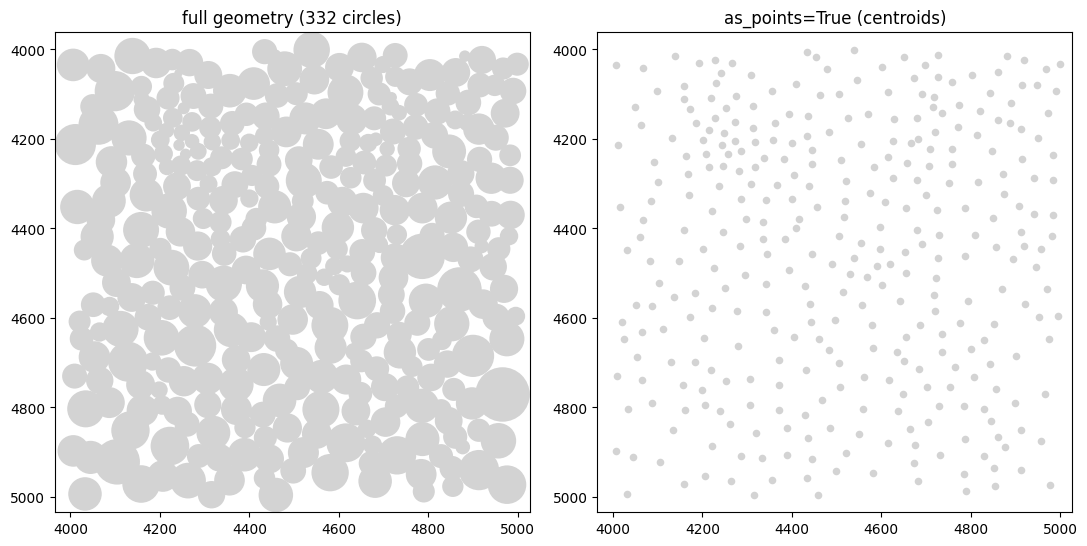

In [2]:
XMIN, YMIN, XMAX, YMAX = 4000, 4000, 5000, 5000  # a 1000 x 1000 micron window
crop = bounding_box_query(
    sdata,
    min_coordinate=[XMIN, YMIN],
    max_coordinate=[XMAX, YMAX],
    axes=("x", "y"),
    target_coordinate_system="global",
)
n_crop = len(crop["cell_circles"])
print(f"{n_crop} cells in the crop")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
crop.pl.render_shapes("cell_circles").pl.show(
    ax=axes[0], title=f"full geometry ({n_crop} circles)"
)
crop.pl.render_shapes("cell_circles", as_points=True, size=30).pl.show(
    ax=axes[1], title="as_points=True (centroids)"
)
fig.tight_layout()

Colour is resolved exactly as for the full geometry — the dot inherits the value
the shape would have had. Here we colour by `total_counts` from the annotating
table; the categorical/continuous handling, `palette`/`cmap`, legends and
colourbars all behave identically.

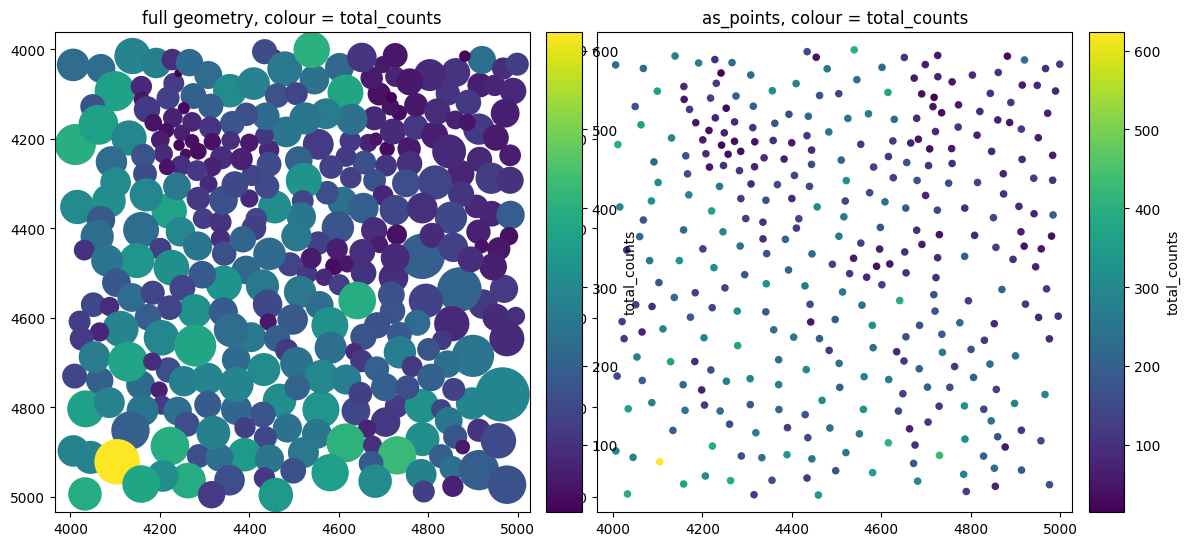

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
crop.pl.render_shapes("cell_circles", color="total_counts", cmap="viridis").pl.show(
    ax=axes[0], title="full geometry, colour = total_counts"
)
crop.pl.render_shapes(
    "cell_circles", color="total_counts", cmap="viridis", as_points=True, size=30
).pl.show(ax=axes[1], title="as_points, colour = total_counts")
fig.tight_layout()

## 2. Labels: segmentation masks as centroids

Xenium has no labels element, so we build a real one from the real cell
boundaries: `rasterize(..., return_regions_as_labels=True)` paints each cell's
polygon with its integer id, giving a proper segmentation mask (pixel value =
cell id).

`render_labels(..., as_points=True)` then draws one dot per label. The centroids
are computed from the *rendered* (display-resolution) raster, so it stays cheap;
`contour_px` and `outline_*` are ignored.

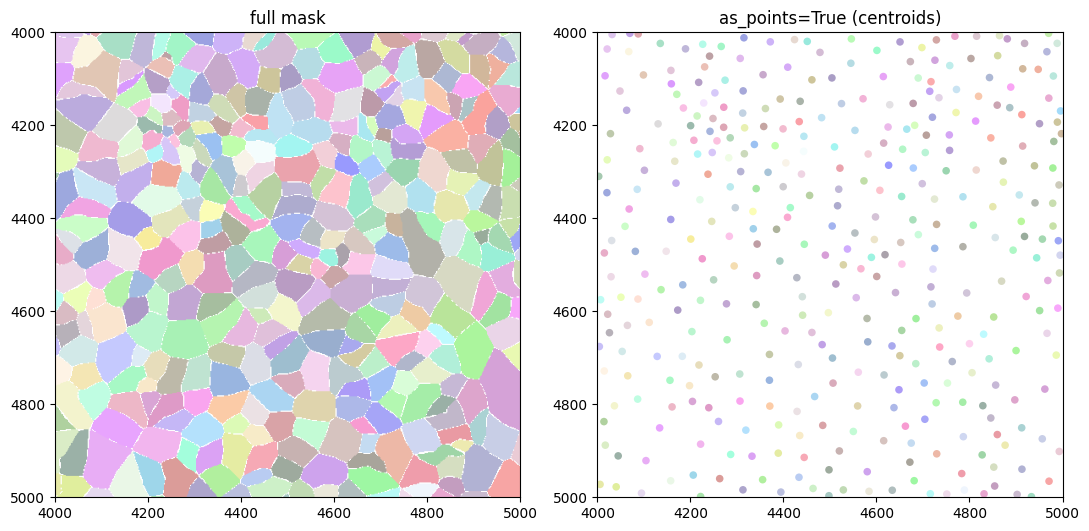

In [4]:
cell_masks = rasterize(
    crop["cell_boundaries"],
    ["x", "y"],
    min_coordinate=[XMIN, YMIN],
    max_coordinate=[XMAX, YMAX],
    target_coordinate_system="global",
    target_unit_to_pixels=1.0,
    return_regions_as_labels=True,
)
crop["cell_masks"] = cell_masks

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
crop.pl.render_labels("cell_masks").pl.show(ax=axes[0], title="full mask")
crop.pl.render_labels("cell_masks", as_points=True, size=30).pl.show(
    ax=axes[1], title="as_points=True (centroids)"
)
fig.tight_layout()

## 3. The speed trade-off

This is why the option exists. We subsample the real cells across a range of
counts and time each rendering, holding the backend at matplotlib so we compare
*drawing N polygons/masks* against *drawing N dots* directly.

In [5]:
def time_best(fn, repeat=3):
    # Best wall-clock of `repeat` runs, closing figures between them.
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        plt.close("all")
        best = min(best, time.perf_counter() - t0)
    return best

In [6]:
# Shapes: draw N circles vs N centroid dots.
circ = sdata["cell_circles"]
shape_ns = [1_000, 5_000, 20_000, 50_000, 100_000, len(circ)]
shape_full, shape_pts = [], []
for n in shape_ns:
    s = SpatialData(shapes={"c": circ.iloc[:n].copy()})
    shape_full.append(time_best(lambda: s.pl.render_shapes("c", method="matplotlib").pl.show()))  # noqa: B023
    shape_pts.append(
        time_best(lambda: s.pl.render_shapes("c", as_points=True, method="matplotlib").pl.show())  # noqa: B023
    )
    print(f"N={n:>7}:  full {shape_full[-1]:6.2f}s   as_points {shape_pts[-1]:5.2f}s   "
          f"({shape_full[-1] / shape_pts[-1]:.0f}x)")

N=   1000:  full   0.03s   as_points  0.01s   (3x)


N=   5000:  full   0.13s   as_points  0.02s   (9x)


N=  20000:  full   0.51s   as_points  0.04s   (14x)


N=  50000:  full   1.27s   as_points  0.09s   (14x)


N= 100000:  full   2.52s   as_points  0.16s   (16x)


N= 167780:  full   4.24s   as_points  0.26s   (16x)


In [7]:
# Labels: draw the filled mask vs N centroid dots. We rasterize progressively
# larger crops (more cells) to grow N.
label_sides = [1_000, 4_000, 8_000, 12_000]
x0, y0 = 2_000, 2_000
label_ns, label_full, label_pts = [], [], []
for side in label_sides:
    cb = bounding_box_query(
        sdata["cell_boundaries"],
        min_coordinate=[x0, y0],
        max_coordinate=[x0 + side, y0 + side],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
    m = rasterize(
        cb, ["x", "y"],
        min_coordinate=[x0, y0], max_coordinate=[x0 + side, y0 + side],
        target_coordinate_system="global", target_unit_to_pixels=1.0,
        return_regions_as_labels=True,
    )
    s = SpatialData(labels={"m": m})
    label_ns.append(len(cb))
    label_full.append(time_best(lambda: s.pl.render_labels("m").pl.show()))  # noqa: B023
    label_pts.append(
        time_best(lambda: s.pl.render_labels("m", as_points=True, method="matplotlib").pl.show())  # noqa: B023
    )
    print(f"N={len(cb):>6}:  full mask {label_full[-1]:5.2f}s   as_points {label_pts[-1]:5.2f}s")

N=   424:  full mask  0.10s   as_points  0.09s


N=  5833:  full mask  0.10s   as_points  0.10s


N= 18606:  full mask  0.12s   as_points  0.12s


N= 39125:  full mask  0.15s   as_points  0.15s


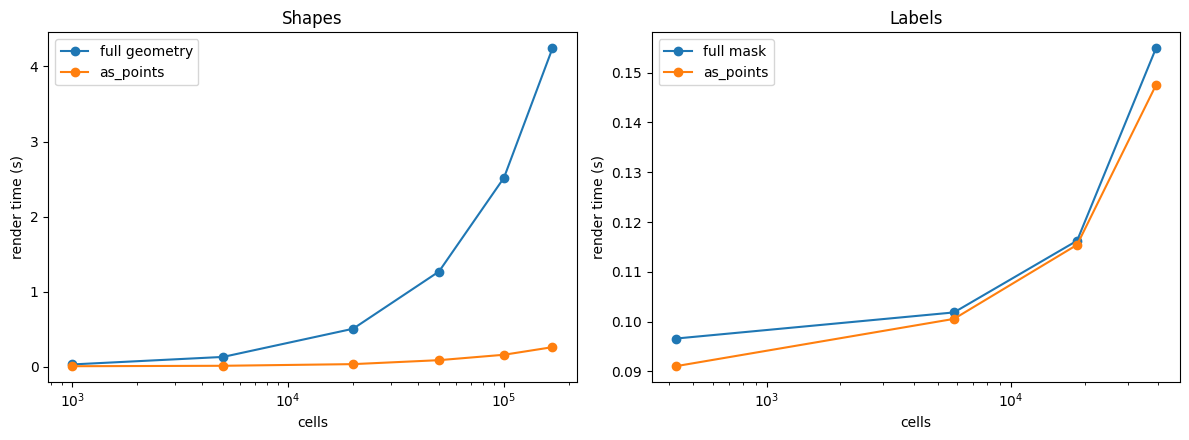

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

axL.plot(shape_ns, shape_full, "o-", label="full geometry")
axL.plot(shape_ns, shape_pts, "o-", label="as_points")
axL.set(title="Shapes", xlabel="cells", ylabel="render time (s)")
axL.set_xscale("log")
axL.legend()

axR.plot(label_ns, label_full, "o-", label="full mask")
axR.plot(label_ns, label_pts, "o-", label="as_points")
axR.set(title="Labels", xlabel="cells", ylabel="render time (s)")
axR.set_xscale("log")
axR.legend()

fig.tight_layout()

The two panels tell different stories, and that is the key lesson:

- **Shapes — a large, growing win.** Every circle is a vector primitive
  matplotlib has to draw; a centroid is one scatter point. At the full section
  (~168 000 cells) `as_points` is on the order of **10–15× faster**, and the gap
  widens with cell count.
- **Labels — essentially free either way.** A labels element renders as a
  *raster* (an `imshow` downsampled to the display), whose cost depends on
  display pixels, not cell count. Computing centroids costs about the same. So
  for labels `as_points` is **not** a speed optimisation — it is a different
  *look* (dots instead of filled regions), useful for decluttering or overlaying
  on an image, at roughly the same price.

Rule of thumb: reach for `as_points` on **shapes** when you have many objects and
don't need their morphology; reach for it on **labels** when you want the
centroid *representation*, not for speed.

## 4. Backend and the ~50 000 rule

The centroid dots can be drawn by either backend, chosen with `method`:

- `method="matplotlib"` (per-glyph scatter) — exact, great up to tens of
  thousands of dots.
- `method="datashader"` (density raster) — scales to millions.
- `method=None` (default) — matplotlib, but **auto-switches to datashader above
  ~50 000 centroids** (`AS_POINTS_DS_AUTO = 50_000`), because matplotlib's
  per-glyph cost (~18 µs/dot) starts to dominate there.

One caveat: datashader aggregates then shades, so it cannot represent "one
distinct random colour per cell" (the default colouring of a label element with
no colour column). In that case it falls back to matplotlib with a warning. With
a real colour column (like below) both backends work; they differ only in look.

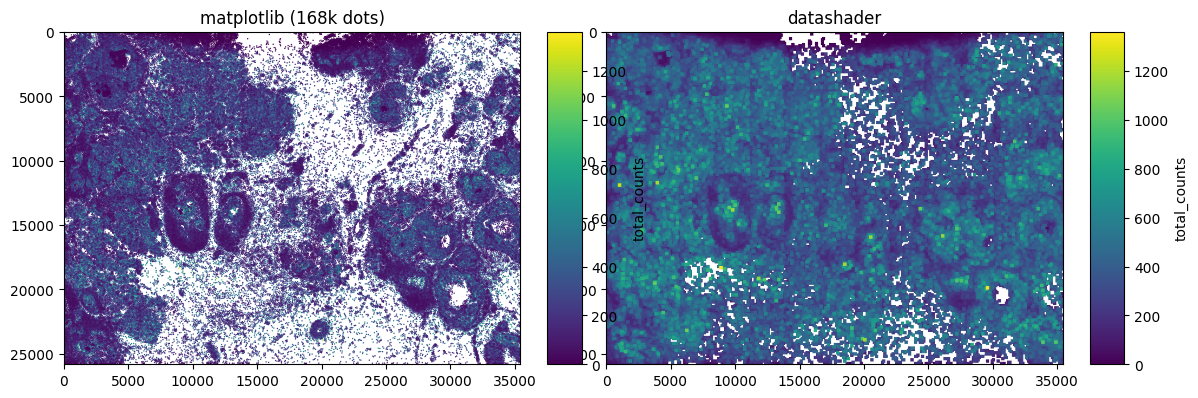

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
sdata.pl.render_shapes(
    "cell_circles", color="total_counts", as_points=True, method="matplotlib"
).pl.show(ax=axes[0], title="matplotlib (168k dots)")
sdata.pl.render_shapes(
    "cell_circles", color="total_counts", as_points=True, method="datashader"
).pl.show(ax=axes[1], title="datashader")
fig.tight_layout()

## When to reach for `as_points`

- **Many shapes, morphology not needed** — a quick overview of hundreds of
  thousands of cells, coloured by a value, without waiting on polygon drawing.
- **Overlaying positions on an image** — dots read more clearly than filled
  masks on top of tissue.
- **Not for label speed** — if you already have a labels element, rendering the
  mask is just as fast; use `as_points` only if you want the dot look.
- **Remember what's dropped** — size, outline and shape are gone. When those
  carry meaning (spot size, cell area, boundary detail), keep the full geometry.

## For reproducibility

In [10]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import spatialdata_plot

%load_ext watermark
# fmt: on
%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy,datashader,pooch

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
matplotlib      : 3.10.9
numpy           : 2.4.4
datashader      : 0.19.0
pooch           : 1.9.0

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

